# Generate Fake Masks using Best Model

This notebook uses the best performing model (`resnet50_3layer_ep50_lr1e-05_pw1.5.pth`) to generate fake masks for the IJmond bbox dataset. The generated masks will be saved in a new subfolder within the IJmond bbox dataset directory.

In [49]:
# Import Required Libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from torchvision import models

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import yaml
import json
import os
from tqdm import tqdm
import cv2

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

%matplotlib inline

Using device: cpu


In [50]:
# Define GuidedBox Model Architecture
class GuidedBoxModel(nn.Module):
    def __init__(self, config):
        super(GuidedBoxModel, self).__init__()
        
        # Load ResNet50 and extract only convolutional feature layers
        resnet = models.resnet50(pretrained=True)
        self.backbone = nn.Sequential(
            resnet.conv1,
            resnet.bn1,
            resnet.relu,
            resnet.maxpool,
            resnet.layer1,  # [B, 256, H/4, W/4]
            resnet.layer2,  # [B, 512, H/8, W/8]
            resnet.layer3,  # [B, 1024, H/16, W/16]
            resnet.layer4,  # [B, 2048, H/32, W/32]
        )
        
        # 3-layer decoder (based on model name resnet50_3layer)
        self.teacher = nn.Sequential(
            nn.Conv2d(2048, 1024, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(1024, 512, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, config['num_classes'], kernel_size=1)
        )
        self.student = nn.Sequential(
            nn.Conv2d(2048, 1024, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(1024, 512, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, config['num_classes'], kernel_size=1)
        )
        self.alpha = config.get('ema_alpha', 0.9)

    def forward(self, images):
        features = self.backbone(images)       # [B, 2048, H/32, W/32]
        student_output = self.student(features)  # [B, num_classes, H/32, W/32]
        
        # Upsample predictions to original image size
        student_output = F.interpolate(student_output, size=images.shape[2:], mode='bilinear', align_corners=False)
        
        return student_output

print("✓ Model architecture defined")

✓ Model architecture defined


In [51]:
# Load Model Configuration and Weights
model_path = "grid_search/resnet50_3layer_ep10_lr1e-05_pw1.5"
config_path = "guidedbox_config.yaml"

# Load configuration
if os.path.exists(config_path):
    with open(config_path, 'r') as file:
        config = yaml.safe_load(file)
    print(f"✓ Configuration loaded from: {config_path}")
else:
    # Create default config based on model name
    config = {
        'num_classes': 1,
        'ema_alpha': 0.9,
        'device': str(device)
    }
    print("⚠️  Using default configuration")

# Load the trained model
if os.path.exists(model_path):
    checkpoint = torch.load(model_path, map_location=device, weights_only=False)
    print(f"✓ Model checkpoint loaded from: {model_path}")
    
    # Initialize model
    model = GuidedBoxModel(config)
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device)
    model.eval()
    
    # Print model info
    if 'best_iou' in checkpoint:
        print(f"  Model Best IoU: {checkpoint['best_iou']:.4f}")
    if 'final_iou' in checkpoint:
        print(f"  Model Final IoU: {checkpoint['final_iou']:.4f}")
    
    print("✓ Model loaded and ready for inference")
else:
    print(f"❌ Model file not found: {model_path}")
    print("Available model files:")
    model_dir = os.path.dirname(model_path)
    if os.path.exists(model_dir):
        for f in os.listdir(model_dir):
            if f.endswith('.pth'):
                print(f"  {f}")

✓ Configuration loaded from: guidedbox_config.yaml
❌ Model file not found: grid_search/resnet50_3layer_ep10_lr1e-05_pw1.5
Available model files:
  lr0.0001_ema0.85_img128_pw3.pth
  lr0.0001_ema0.85_img128_pw5.pth
  lr0.0001_ema0.85_img128_pw7.pth
  lr0.0001_ema0.85_img128_pw9.pth
  lr0.0001_ema0.85_img256_pw3.pth
  lr0.0001_ema0.85_img256_pw5.pth
  lr0.0001_ema0.85_img256_pw7.pth
  lr0.0001_ema0.85_img256_pw9.pth
  lr0.0001_ema0.85_img512_pw5.pth
  lr0.0001_ema0.85_img512_pw7.pth
  lr0.0001_ema0.95_img128_pw3.pth
  lr0.0001_ema0.95_img128_pw5.pth
  lr0.0001_ema0.95_img128_pw7.pth
  lr0.0001_ema0.95_img256_pw3.pth
  lr0.0001_ema0.95_img256_pw5.pth
  lr0.0001_ema0.95_img256_pw7.pth
  lr0.0001_ema0.95_img512_pw3.pth
  lr0.0001_ema0.95_img512_pw5.pth
  lr0.0001_ema0.95_img512_pw7.pth
  lr0.0001_ema0.95_img512_pw9.pth
  lr0.0001_ema0.9_img128_pw3.pth
  lr0.0001_ema0.9_img128_pw5.pth
  lr0.0001_ema0.9_img128_pw9.pth
  lr0.0001_ema0.9_img256_pw3.pth
  lr0.0001_ema0.9_img256_pw5.pth
  lr0.0001

In [44]:
# Setup Dataset Paths and Output Directory
img_npy_path = "dataset/ijmond_bbox/img_npy"
output_masks_path = "dataset/ijmond_bbox/generated_masks"

# Create output directory
os.makedirs(output_masks_path, exist_ok=True)
print(f"✓ Output directory created: {output_masks_path}")

# Check input data
if os.path.exists(img_npy_path):
    npy_files = [f for f in os.listdir(img_npy_path) if f.endswith('.npy')]
    print(f"✓ Found {len(npy_files)} .npy image files in: {img_npy_path}")
    
    # Show some example files
    print("Sample files:")
    for i, file in enumerate(npy_files[:5]):
        print(f"  {i+1}. {file}")
    if len(npy_files) > 5:
        print(f"  ... and {len(npy_files) - 5} more files")
else:
    print(f"❌ Input directory not found: {img_npy_path}")
    print("Available directories:")
    if os.path.exists("dataset"):
        for item in os.listdir("dataset"):
            print(f"  dataset/{item}")

✓ Output directory created: dataset/ijmond_bbox/generated_masks
✓ Found 610 .npy image files in: dataset/ijmond_bbox/img_npy
Sample files:
  1. 10.npy
  2. 1000.npy
  3. 1001.npy
  4. 1005.npy
  5. 1006.npy
  ... and 605 more files


In [45]:
# Image Preprocessing Functions
def preprocess_image(image_array, target_size=512):
    """
    Preprocess numpy image for model inference
    Args:
        image_array: numpy array (H, W, 3) uint8
        target_size: target image size for model
    Returns:
        torch.Tensor: preprocessed image tensor (1, 3, target_size, target_size)
    """
    # Convert to PIL Image and resize
    image_pil = Image.fromarray(image_array).resize((target_size, target_size), Image.BILINEAR)
    
    # Convert to tensor and normalize
    image_tensor = TF.to_tensor(image_pil)  # [3, H, W], [0, 1]
    
    # Normalize with ImageNet stats (as used during training)
    image_tensor = TF.normalize(image_tensor, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    
    # Add batch dimension
    image_tensor = image_tensor.unsqueeze(0)  # [1, 3, H, W]
    
    return image_tensor

def postprocess_mask(prediction_tensor, original_size, threshold=0.5):
    """
    Postprocess model prediction to create binary mask
    Args:
        prediction_tensor: model output tensor (1, 1, H, W)
        original_size: (width, height) of original image
        threshold: threshold for binarization
    Returns:
        numpy array: binary mask (H, W) uint8
    """
    # Apply sigmoid to get probabilities
    prob_mask = torch.sigmoid(prediction_tensor).squeeze().cpu().numpy()
    
    # Resize to original image size
    prob_mask_pil = Image.fromarray((prob_mask * 255).astype(np.uint8)).resize(original_size, Image.NEAREST)
    prob_mask_resized = np.array(prob_mask_pil) / 255.0
    
    # Binarize
    binary_mask = (prob_mask_resized > threshold).astype(np.uint8) * 255
    
    return binary_mask

print("✓ Preprocessing functions defined")

✓ Preprocessing functions defined


In [46]:
# Generate Masks for All Images
if 'model' in locals() and 'npy_files' in locals():
    print("🚀 Starting mask generation...")
    print("=" * 60)
    
    # Model parameters (based on best model name)
    target_size = 512  # Based on model training
    batch_size = 8
    threshold = 0.5
    
    generated_count = 0
    failed_count = 0
    
    # Process images in batches for efficiency
    for i in tqdm(range(0, len(npy_files), batch_size), desc="Processing batches"):
        batch_files = npy_files[i:i + batch_size]
        batch_images = []
        batch_info = []
        
        # Load and preprocess batch
        for npy_file in batch_files:
            try:
                # Load image
                img_path = os.path.join(img_npy_path, npy_file)
                image_array = np.load(img_path)  # (H, W, 3)
                original_size = (image_array.shape[1], image_array.shape[0])  # (W, H)
                
                # Preprocess
                preprocessed = preprocess_image(image_array, target_size)
                batch_images.append(preprocessed)
                batch_info.append({
                    'filename': npy_file,
                    'original_size': original_size,
                    'original_shape': image_array.shape
                })             
            except Exception as e:
                print(f"❌ Error loading {npy_file}: {e}")
                failed_count += 1
                continue
        
        if not batch_images:
            continue
            
        # Concatenate batch
        batch_tensor = torch.cat(batch_images, dim=0).to(device)
        
        # Generate predictions
        with torch.no_grad():
            predictions = model(batch_tensor)  # (batch_size, 1, target_size, target_size)
        
        # Save masks
        for j, (pred, info) in enumerate(zip(predictions, batch_info)):
            try:
                # Postprocess prediction
                binary_mask = postprocess_mask(pred.unsqueeze(0), info['original_size'], threshold)
                
                # Save mask
                mask_filename = info['filename'].replace('.npy', '_mask.png')
                mask_path = os.path.join(output_masks_path, mask_filename)
                
                mask_image = Image.fromarray(binary_mask, mode='L')
                mask_image.save(mask_path)
                
                generated_count += 1
                
            except Exception as e:
                print(f"❌ Error processing {info['filename']}: {e}")
                failed_count += 1
    
    print("\\n" + "=" * 60)
    print("✅ MASK GENERATION COMPLETE!")
    print(f"   • Successfully generated: {generated_count} masks")
    print(f"   • Failed: {failed_count} images")
    print(f"   • Success rate: {generated_count/(generated_count+failed_count)*100:.1f}%")
    print(f"   • Output directory: {output_masks_path}")
    print("=" * 60)
    
else:
    print("❌ Model not loaded or no input files found")

🚀 Starting mask generation...


Processing batches: 100%|██████████| 77/77 [12:24<00:00,  9.67s/it]

\n============================================================
✅ MASK GENERATION COMPLETE!
   • Successfully generated: 610 masks
   • Failed: 0 images
   • Success rate: 100.0%
   • Output directory: dataset/ijmond_bbox/generated_masks


🖼️  Visualizing sample results...


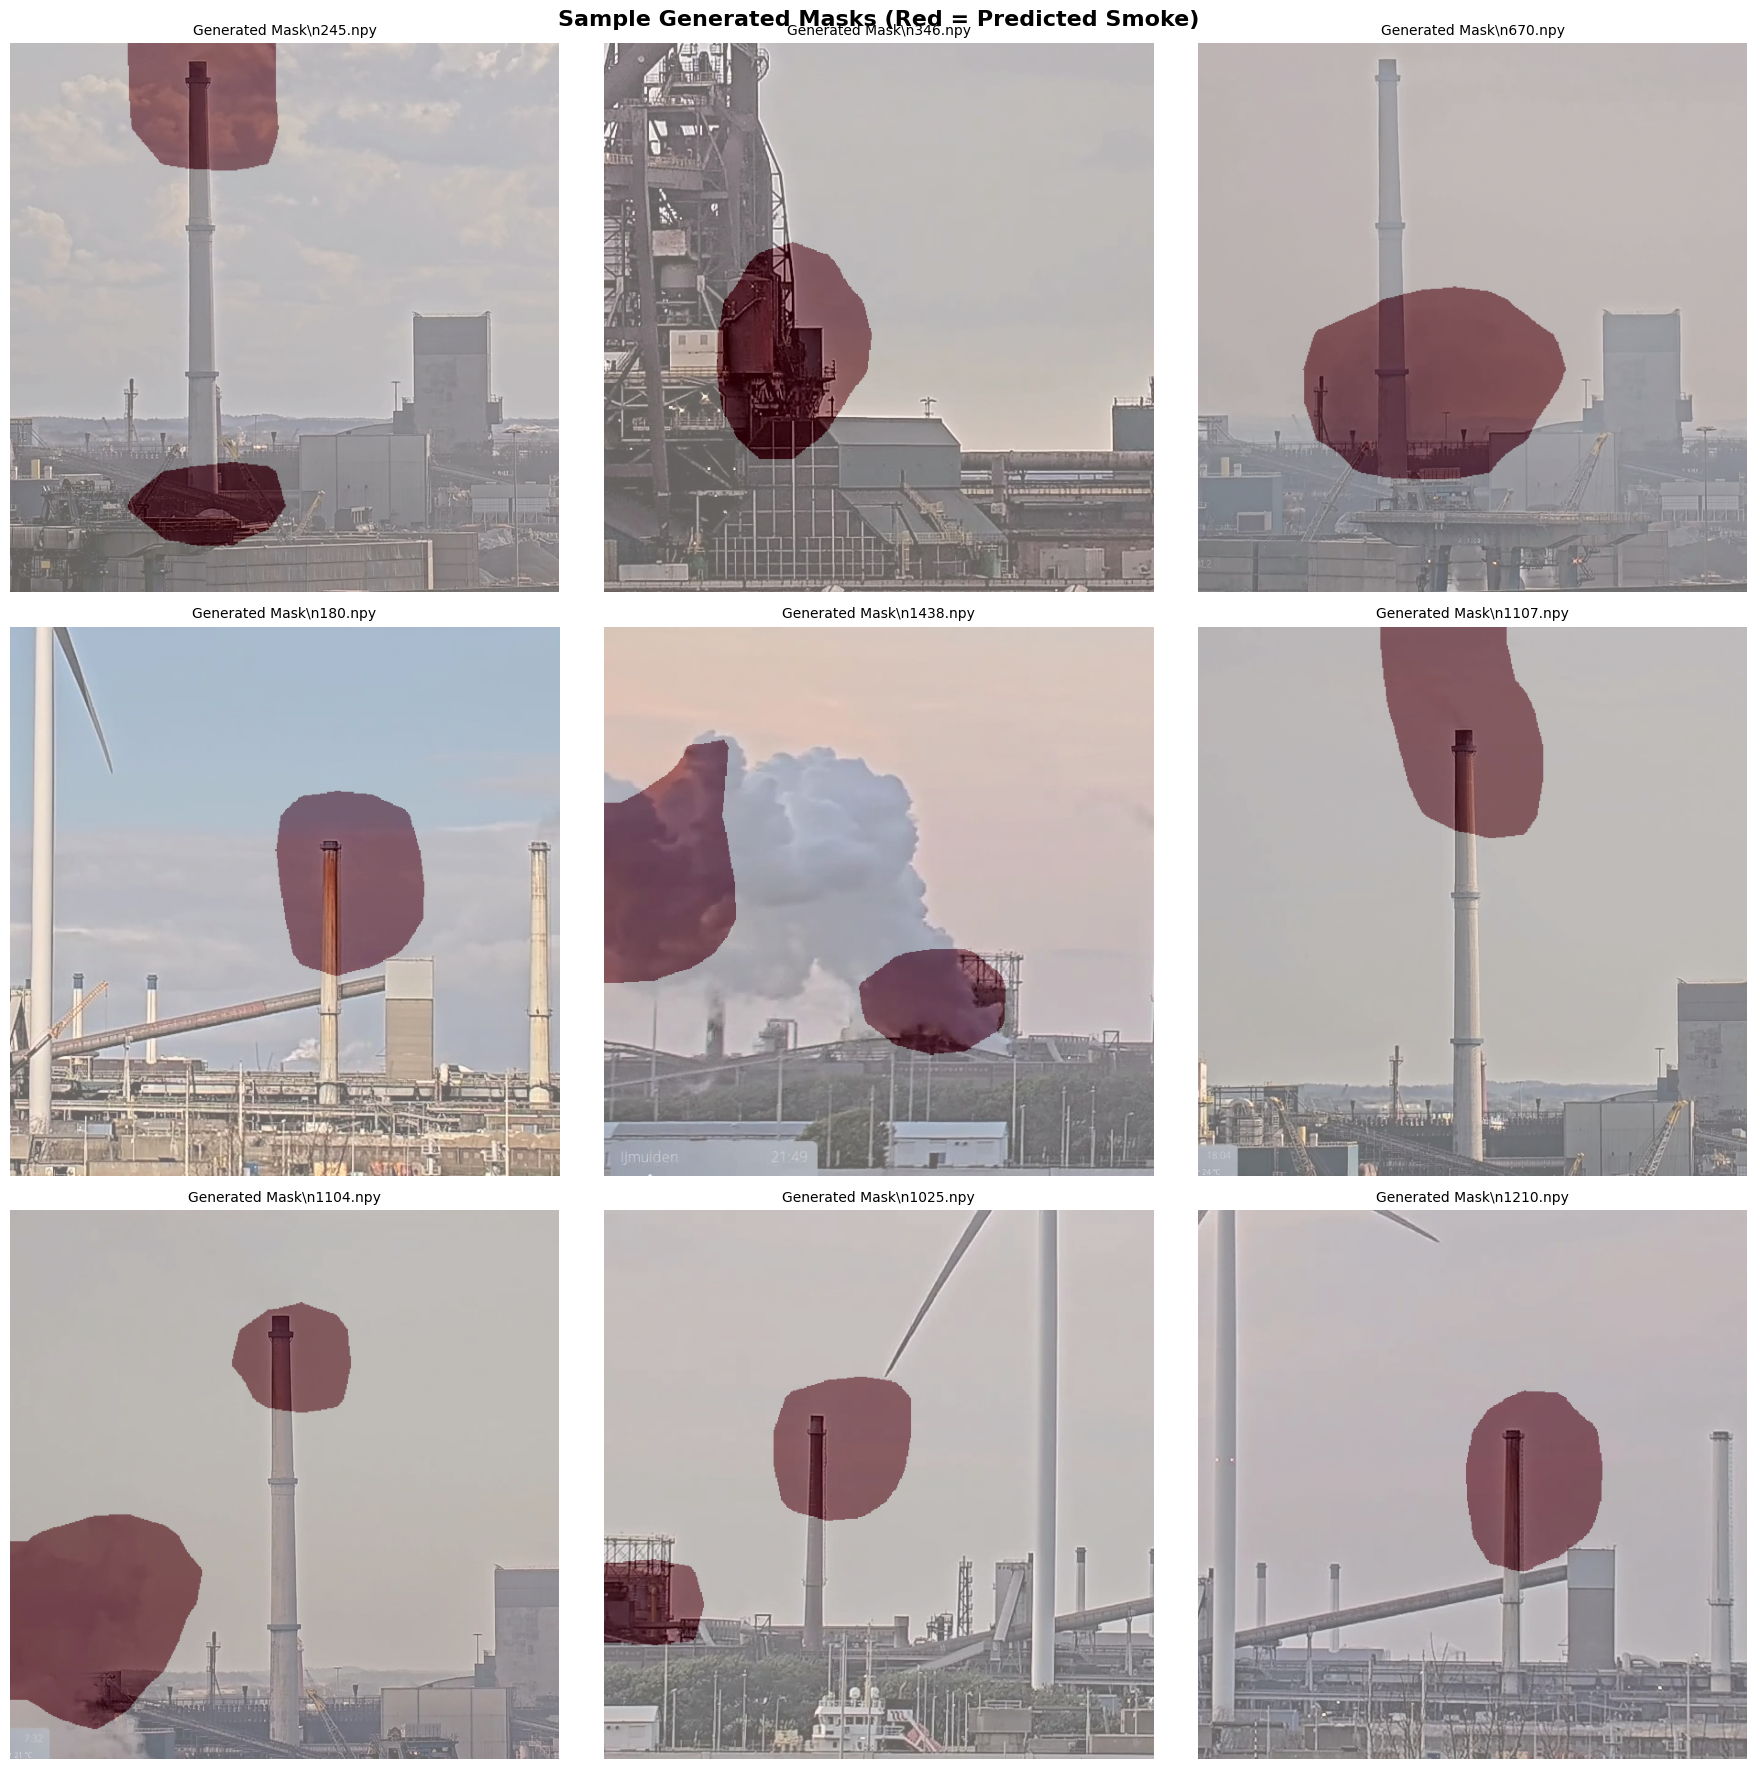

\n📊 MASK STATISTICS:
   • Total masks generated: 610
   • Average mask file size: 1829 bytes
   • Average smoke coverage: 8.8%
   • Coverage range: 3.5% - 16.3%


In [53]:
# Visualize Sample Results
if generated_count > 0:
    print("🖼️  Visualizing sample results...")
    
    # Get some random samples to visualize
    mask_files = [f for f in os.listdir(output_masks_path) if f.endswith('_mask.png')]
    sample_files = np.random.choice(mask_files, min(9, len(mask_files)), replace=False)
    
    fig, axes = plt.subplots(3, 3, figsize=(18, 18))
    axes = axes.flatten()
    
    for i, mask_file in enumerate(sample_files):
        # Load original image
        img_file = mask_file.replace('_mask.png', '.npy')
        img_path = os.path.join(img_npy_path, img_file)
        mask_path = os.path.join(output_masks_path, mask_file)
        
        if os.path.exists(img_path) and os.path.exists(mask_path):
            # Load image and mask
            original_img = np.load(img_path)
            generated_mask = Image.open(mask_path)
            
            # Create subplot with original and mask overlay
            ax = axes[i]
            ax.imshow(original_img)
            ax.imshow(np.array(generated_mask), alpha=0.4, cmap='Reds')
            ax.set_title(f"Generated Mask\\n{img_file}", fontsize=10)
            ax.axis('off')
    
    # Hide unused subplots
    for i in range(len(sample_files), len(axes)):
        axes[i].axis('off')
    
    plt.suptitle("Sample Generated Masks (Red = Predicted Smoke)", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\\n📊 MASK STATISTICS:")
    print(f"   • Total masks generated: {len(mask_files)}")
    print(f"   • Average mask file size: {np.mean([os.path.getsize(os.path.join(output_masks_path, f)) for f in mask_files[:10]]):.0f} bytes")
    
    # Analyze mask coverage
    sample_coverages = []
    for mask_file in mask_files[:20]:  # Sample first 20 masks
        mask_path = os.path.join(output_masks_path, mask_file)
        mask = np.array(Image.open(mask_path))
        coverage = (mask > 0).sum() / mask.size * 100
        sample_coverages.append(coverage)
    
    print(f"   • Average smoke coverage: {np.mean(sample_coverages):.1f}%")
    print(f"   • Coverage range: {np.min(sample_coverages):.1f}% - {np.max(sample_coverages):.1f}%")

In [54]:
# Save Generation Summary
if generated_count > 0:
    # Create a summary report
    summary = {
        'model_used': model_path,
        'model_performance': {
            'best_iou': checkpoint.get('best_iou', 'unknown'),
            'final_iou': checkpoint.get('final_iou', 'unknown')
        },
        'generation_settings': {
            'target_size': target_size,
            'threshold': threshold,
            'batch_size': batch_size
        },
        'results': {
            'total_input_images': len(npy_files),
            'successfully_generated': generated_count,
            'failed': failed_count,
            'success_rate': generated_count/(generated_count+failed_count)*100
        },
        'output_directory': output_masks_path,
        'mask_files_pattern': '*_mask.png'
    }
    
    # Save summary to JSON
    summary_path = os.path.join(output_masks_path, 'generation_summary.json')
    with open(summary_path, 'w') as f:
        json.dump(summary, f, indent=2)
    
    print("💾 GENERATION SUMMARY SAVED")
    print(f"   Summary file: {summary_path}")
    print("\\n🎉 ALL DONE!")
    print(f"   Generated masks are available in: {output_masks_path}")
    print(f"   You can now use these masks for further training or evaluation.")
    
    # Instructions for next steps
    print("\\n📝 NEXT STEPS:")
    print("   1. Review the generated masks visually")
    print("   2. Use masks for training new segmentation models")
    print("   3. Compare with ground truth if available")
    print("   4. Adjust threshold if needed and regenerate")

💾 GENERATION SUMMARY SAVED
   Summary file: dataset/ijmond_bbox/generated_masks\generation_summary.json
\n🎉 ALL DONE!
   Generated masks are available in: dataset/ijmond_bbox/generated_masks
   You can now use these masks for further training or evaluation.
\n📝 NEXT STEPS:
   1. Review the generated masks visually
   2. Use masks for training new segmentation models
   3. Compare with ground truth if available
   4. Adjust threshold if needed and regenerate
